In [1]:
!pip install emoji langdetect keybert sentence-transformers umap-learn -q
!pip install opentelemetry-api==1.25.0 opentelemetry-sdk==1.25.0 opentelemetry-exporter-otlp-proto-grpc==1.25.0 -q
!pip install chromadb --upgrade -q
!pip install gensim -q
!pip install pyLDAvis -q
!pip install spacy -q
!python -m spacy download es_core_news_lg -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 50.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.0/107.0 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.5/130.5 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 35.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import emoji
import re
from collections import Counter
import matplotlib.pyplot as plt
import os
import random


import spacy
from collections import defaultdict


import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

from nltk.util import ngrams

from sklearn.ensemble import IsolationForest
from sklearn.metrics.pairwise import cosine_distances
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_distances

from langdetect import detect, DetectorFactory
from keybert import KeyBERT
import umap

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)

from gensim import corpora
from gensim.models import LsiModel, LdaModel, HdpModel, LdaMulticore
np.random.seed(SEED)
from gensim.models import CoherenceModel
import pyLDAvis
import pyLDAvis.gensim_models
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import chromadb
from pathlib import Path

DB_PATH_RESUMENES = Path("/content/drive/MyDrive/NLP_PRACTICA/Persist/chroma_db_resumenes_qwen")
DB_PATH_LIBRO = "/content/drive/MyDrive/NLP_PRACTICA/Persist/libro_largo_qwen"
client_libro = chromadb.PersistentClient(path=DB_PATH_LIBRO)
coll_name_libro = client_libro.list_collections()[0].name

collection_libro = client_libro.get_collection(coll_name_libro)
COLLECTION_NAME = "resumenes_got"

client = chromadb.PersistentClient(path=str(DB_PATH_RESUMENES))
collection = client.get_collection(COLLECTION_NAME)

In [ ]:
data = collection.get()
data_libro = collection_libro.get()

df_resumenes = pd.DataFrame({
    'ids': data['ids'],
    'documents': data['documents'],
    'metadatas': data['metadatas']
})

if df_resumenes['metadatas'].notnull().any():
    df_meta = pd.json_normalize(df_resumenes['metadatas'])
    df_resumenes = pd.concat([df_resumenes.drop('metadatas', axis=1), df_meta], axis=1)


df_libro = pd.DataFrame({
    'ids': data_libro['ids'],
    'documents': data_libro['documents'],
    'metadatas': data_libro['metadatas']
})

if df_libro['metadatas'].notnull().any():
    df_meta_libro = pd.json_normalize(df_libro['metadatas'])
    df_libro = pd.concat([df_libro.drop('metadatas', axis=1), df_meta_libro], axis=1)

df = pd.concat([df_resumenes, df_libro], ignore_index=True)

print(f"Total registros en df: {len(df)}")
display(df_libro.head(5))
display(df_resumenes.head(5))

Total registros en df: 648


,ids,documents,main_event,chapter_order,pov,chunk_index,chapter_title,houses,chapter_id,keywords,characters,locations
0,agot_001_bran_0,Chapter: BRAN (1)\nChapter order: 1\nPOV: BRAN...,Bran presencia la decapitación de un hombre ac...,1,BRAN,0,BRAN (1),"Stark, Greyjoy, Baratheon",agot_001_bran,"decapitación, justicia, rey, salvajes, Mance R...","Bran, Robb, Jon Nieve, Eddard Stark, Theon Gre...","Invernalia, el fortín de las colinas, el puente"
1,agot_001_bran_1,Chapter: BRAN (1)\nChapter order: 1\nPOV: BRAN...,Bran y su hermano Robb encuentran lobos huargo...,1,BRAN,1,BRAN (1),"Stark, Greyjoy",agot_001_bran,"Bran, Robb, Jon, lobos huargos, nieve, Muro, S...","Bran, Robb, Jon, Jory, Theon Greyjoy, Hullen","el norte del reino, el puente, el Muro"
2,agot_001_bran_2,Chapter: BRAN (1)\nChapter order: 1\nPOV: BRAN...,Bran y sus hermanos reciben cinco cachorros de...,1,BRAN,2,BRAN (1),"Stark, Greyjoy",agot_001_bran,"Bran, Jon, cachorros, lobos, Stark, Greyjoy, I...","Bran, Jory, Robb, Jon, Hullen, Theon Greyjoy, ...","Invernalia, el norte"
3,agot_002_catelyn_0,Chapter: CATELYN (1)\nChapter order: 2\nPOV: C...,Catelyn se reúne con su esposo Ned en el bosqu...,2,CATELYN,0,CATELYN (1),"Tully, Stark",agot_002_catelyn,"Catelyn, Ned, Bosque de dioses, Aguasdulces, I...","Catelyn, Ned, Bran, Arya, Sansa, Rickon","Aguasdulces, Invernalia, El bosque de dioses, ..."
4,agot_002_catelyn_1,Chapter: CATELYN (1)\nChapter order: 2\nPOV: C...,,2,CATELYN,1,CATELYN (1),,agot_002_catelyn,,,


,ids,documents,chapter,paragraph_id
0,Juego_de_Tronos-Prólogo_0,"Dos hombres de la Guardia de la Noche , Will y...",Juego de Tronos-Prólogo,0
1,Juego_de_Tronos-Prólogo_1,"Will le lleva allí, dejando atrás Gared para p...",Juego de Tronos-Prólogo,1
2,Juego_de_Tronos-Capítulo_1_0,"Bran viaja con su padre, Lord Eddard Stark , y...",Juego de Tronos-Capítulo 1,0
3,Juego_de_Tronos-Capítulo_1_1,"De camino a Invernalia , Robb y Jon discuten s...",Juego de Tronos-Capítulo 1,1
4,Juego_de_Tronos-Capítulo_1_2,Jon les alcanza para que vean lo que Robb y él...,Juego de Tronos-Capítulo 1,2


In [ ]:
documents_libro = [str(text).split() for text in df_libro['documents']]

dictionary_libro = corpora.Dictionary(documents_libro)

corpus_libro = [dictionary_libro.doc2bow(doc) for doc in documents_libro]

documents_resumenes = [str(text).split() for text in df_resumenes['documents']]

dictionary_resumenes = corpora.Dictionary(documents_resumenes)

corpus_resumenes = [dictionary_resumenes.doc2bow(doc) for doc in documents_resumenes]

documents_total = [str(text).split() for text in df['documents']]

dictionary_total = corpora.Dictionary(documents_total)

corpus_total = [dictionary_total.doc2bow(doc) for doc in documents_total]


In [ ]:
nlp = spacy.load("es_core_news_lg")

# all_text para búsquedas de menciones — texto plano de df_libro
all_text = " ".join(df_libro['documents'].dropna().tolist())

POV_GENDER = {
    "BRAN": "M", "JON": "M", "EDDARD": "M", "TYRION": "M", "ROBB": "M",
    "CATELYN": "F", "SANSA": "F", "ARYA": "F", "DAENERYS": "F",
}

CHAR_GENDER = {
    "Ned": "M", "Eddard": "M", "Jon": "M", "Bran": "M", "Robb": "M",
    "Tyrion": "M", "Jaime": "M", "Robert": "M", "Theon": "M", "Hodor": "M",
    "Varys": "M", "Meñique": "M", "Jorah": "M", "Viserys": "M", "Drogo": "M",
    "Benjen": "M", "Maestre Luwin": "M", "Ser Rodrik": "M", "Syrio": "M",
    "Sandor": "M", "Gregor": "M", "Jory": "M", "Hullen": "M",
    "Gared": "M", "Will": "M", "Rickon": "M",
    "Catelyn": "F", "Sansa": "F", "Arya": "F", "Daenerys": "F",
    "Cersei": "F", "Lysa": "F", "Lyanna": "F", "Septa Mordane": "F",
    "Shae": "F", "Irri": "F", "Doreah": "F",
}

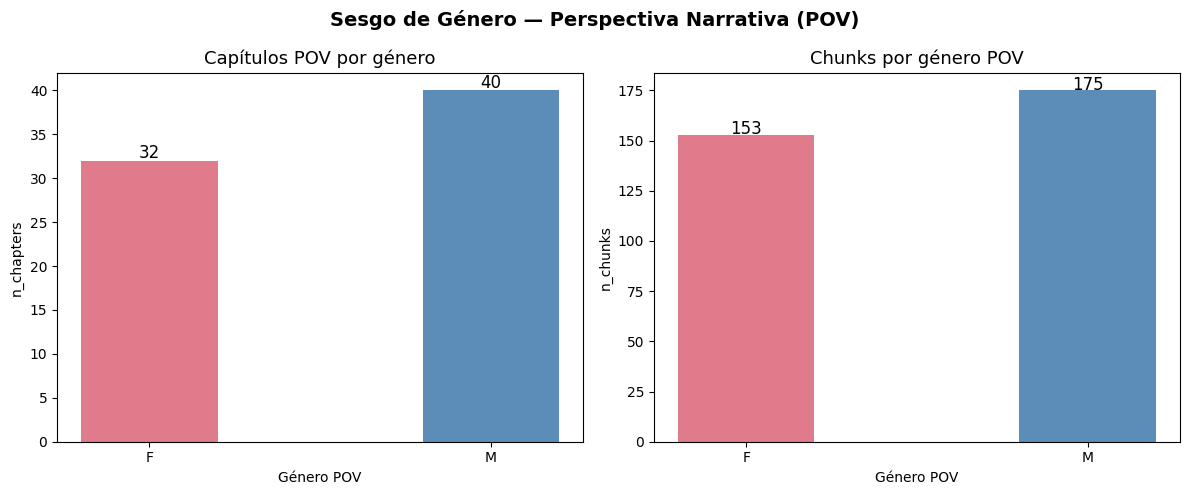

pov_gender  n_chunks
         F       153
         M       175

Ratio F/M chunks: 0.87


In [ ]:
# %% [sesgo_1_pov_distribucion]
df_pov = df_libro[df_libro['pov'].notna()].copy()
df_pov['pov_gender'] = df_pov['pov'].str.upper().str.strip().map(POV_GENDER)

chunks_by_gender = df_pov.groupby('pov_gender').size().reset_index(name='n_chunks')
chapters_by_gender = df_pov.groupby('pov_gender')['chapter_id'].nunique().reset_index(name='n_chapters')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, data, title, col in zip(
    axes,
    [chapters_by_gender, chunks_by_gender],
    ["Capítulos POV por género", "Chunks por género POV"],
    ['n_chapters', 'n_chunks']
):
    bars = ax.bar(data['pov_gender'], data[col], color=['#E07B8C', '#5B8DB8'], width=0.4)
    for bar, val in zip(bars, data[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(val), ha='center', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Género POV")
    ax.set_ylabel(col)

plt.suptitle("Sesgo de Género — Perspectiva Narrativa (POV)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(chunks_by_gender.to_string(index=False))
f_chunks = chunks_by_gender.set_index('pov_gender').loc['F', 'n_chunks']
m_chunks = chunks_by_gender.set_index('pov_gender').loc['M', 'n_chunks']
print(f"\nRatio F/M chunks: {f_chunks/m_chunks:.2f}")

Menciones totales por género:
genero
F    3003
M    7324
Name: menciones, dtype: int64
Ratio M/F: 2.44x más menciones masculinas


/tmp/ipykernel_7477/3547256065.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top20['personaje'], rotation=45, ha='right')


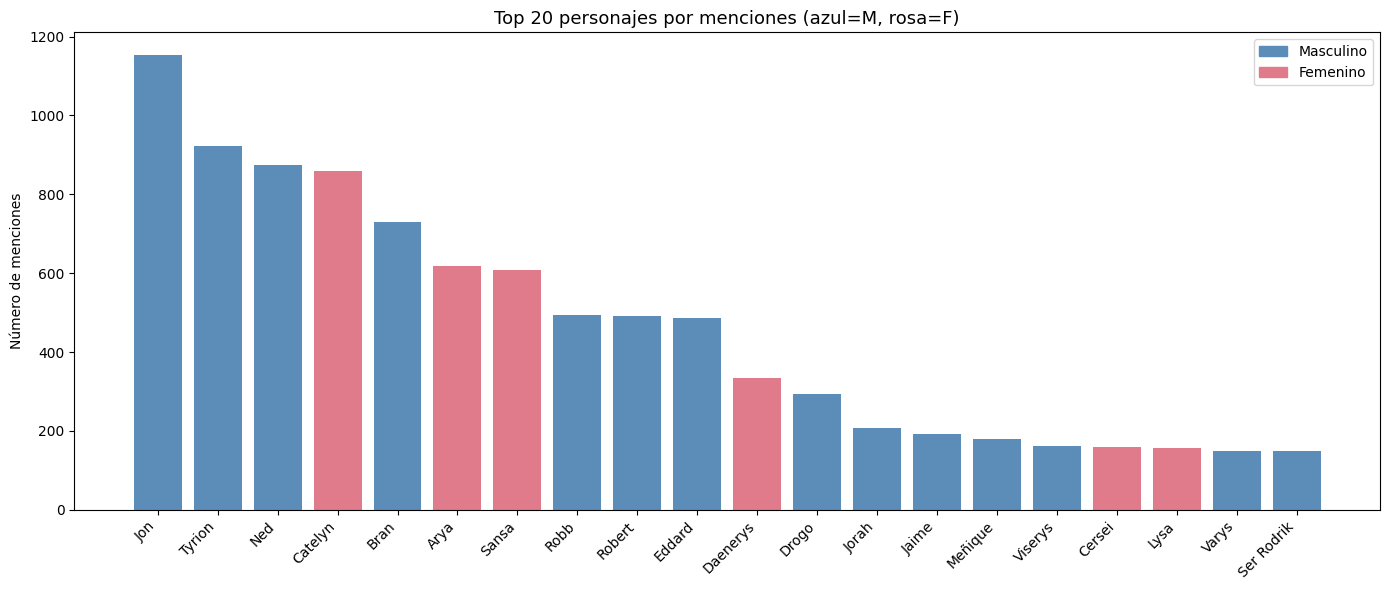

In [ ]:
# %% [sesgo_1_menciones_personajes]
mention_counts = defaultdict(int)
for char in CHAR_GENDER:
    mention_counts[char] = len(re.findall(r'\b' + re.escape(char) + r'\b', all_text, re.IGNORECASE))

mention_df = pd.DataFrame([
    {'personaje': char, 'menciones': cnt, 'genero': CHAR_GENDER[char]}
    for char, cnt in mention_counts.items() if cnt > 0
]).sort_values('menciones', ascending=False)

gender_totals = mention_df.groupby('genero')['menciones'].sum()
print("Menciones totales por género:")
print(gender_totals)
print(f"Ratio M/F: {gender_totals['M']/gender_totals['F']:.2f}x más menciones masculinas")

top20 = mention_df.head(20)
colors = ['#5B8DB8' if g == 'M' else '#E07B8C' for g in top20['genero']]

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(top20['personaje'], top20['menciones'], color=colors)
ax.set_xticklabels(top20['personaje'], rotation=45, ha='right')
ax.set_title("Top 20 personajes por menciones (azul=M, rosa=F)", fontsize=13)
ax.set_ylabel("Número de menciones")

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#5B8DB8', label='Masculino'), Patch(color='#E07B8C', label='Femenino')])
plt.tight_layout()
plt.show()

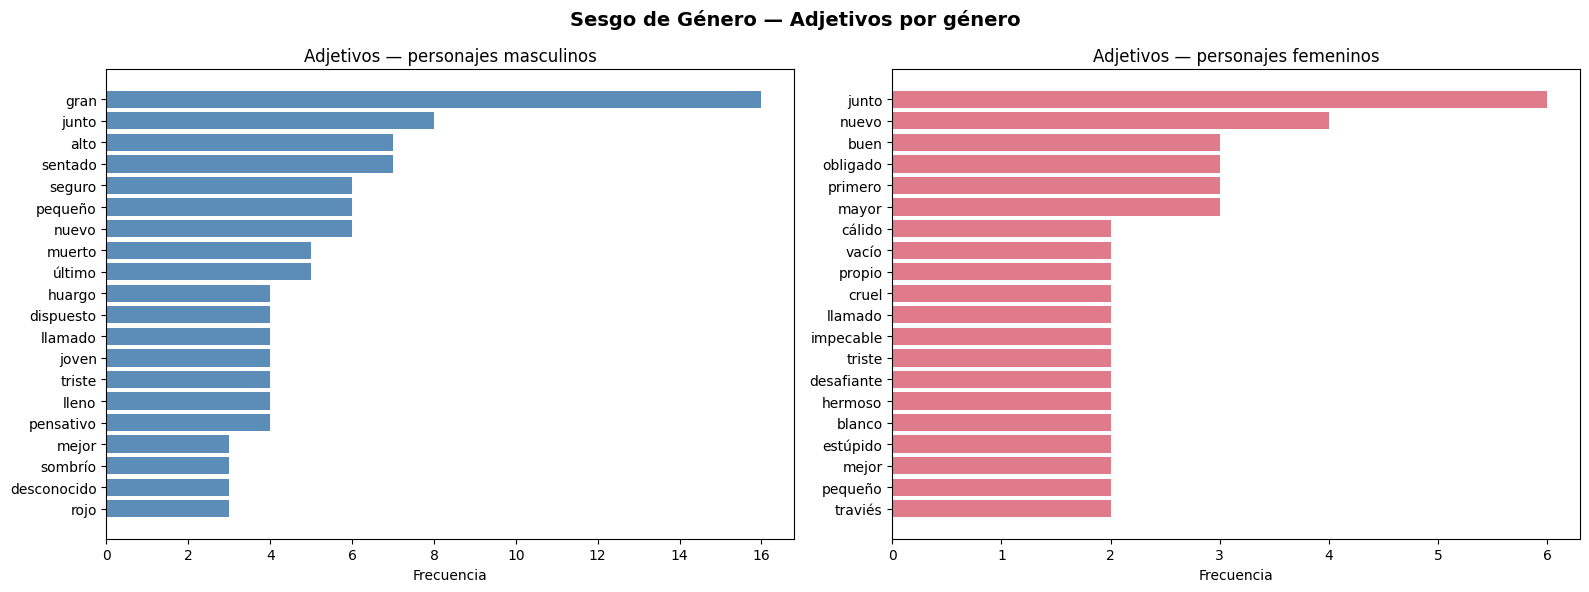

In [ ]:
# %% [sesgo_1_adjetivos_genero]
male_adjectives = []
female_adjectives = []

for text in df_libro['documents'].dropna():
    doc = nlp(text[:2000])
    for token in doc:
        if token.pos_ == "ADJ":
            window = doc[max(0, token.i-4):min(len(doc), token.i+4)]
            for w in window:
                if w.text in CHAR_GENDER:
                    if CHAR_GENDER[w.text] == 'M':
                        male_adjectives.append(token.lemma_.lower())
                    else:
                        female_adjectives.append(token.lemma_.lower())

male_top = Counter(male_adjectives).most_common(20)
female_top = Counter(female_adjectives).most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, data, title, color in zip(
    axes,
    [male_top, female_top],
    ["Adjetivos — personajes masculinos", "Adjetivos — personajes femeninos"],
    ['#5B8DB8', '#E07B8C']
):
    if not data:
        ax.set_title(f"{title} (sin datos)")
        continue
    words, counts = zip(*data)
    ax.barh(list(words)[::-1], list(counts)[::-1], color=color)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Frecuencia")

plt.suptitle("Sesgo de Género — Adjetivos por género", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

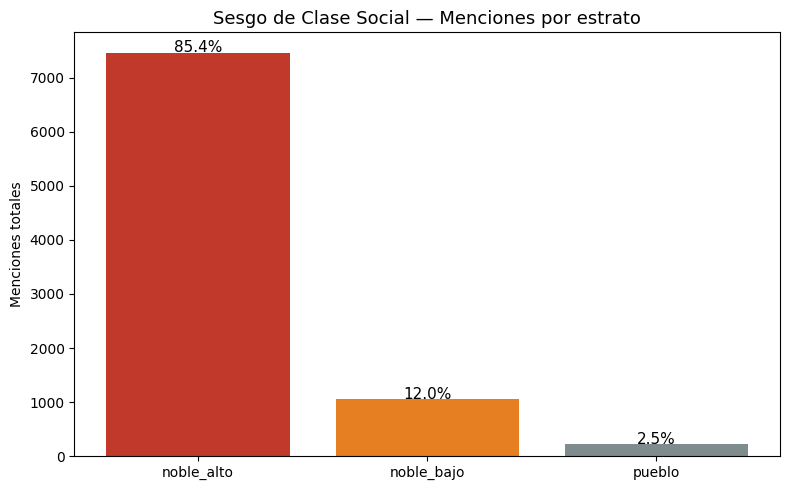

     clase  menciones  porcentaje
noble_alto       7466   85.442893
noble_bajo       1050   12.016480
    pueblo        222    2.540627


In [ ]:
# %% [sesgo_2_clase_social]
CLASS_TAXONOMY = {
    "noble_alto": ["Ned", "Eddard", "Catelyn", "Robb", "Sansa", "Arya", "Bran",
                   "Robert", "Cersei", "Jaime", "Tyrion", "Daenerys", "Viserys",
                   "Lysa", "Drogo", "Rickon"],
    "noble_bajo":  ["Theon", "Jorah", "Meñique", "Varys",
                    "Ser Rodrik", "Maestre Luwin", "Syrio", "Sandor"],
    "pueblo":      ["Hodor", "Gared", "Will", "Rakharo", "Irri", "Doreah"],
}

char_class = {c: cls for cls, chars in CLASS_TAXONOMY.items() for c in chars}

class_mentions = defaultdict(int)
for char, cls in char_class.items():
    class_mentions[cls] += len(re.findall(r'\b' + re.escape(char) + r'\b', all_text, re.IGNORECASE))

class_df = pd.DataFrame(list(class_mentions.items()), columns=['clase', 'menciones'])
class_df['porcentaje'] = class_df['menciones'] / class_df['menciones'].sum() * 100

colors_class = {'noble_alto': '#C0392B', 'noble_bajo': '#E67E22', 'pueblo': '#7F8C8D'}
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(class_df['clase'], class_df['menciones'],
              color=[colors_class[c] for c in class_df['clase']])
for bar, row in zip(bars, class_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{row.porcentaje:.1f}%", ha='center', fontsize=11)
ax.set_title("Sesgo de Clase Social — Menciones por estrato", fontsize=13)
ax.set_ylabel("Menciones totales")
plt.tight_layout()
plt.show()

print(class_df.to_string(index=False))

In [ ]:
# %% [sesgo_2_chunks_pueblo]
pueblo_chars = CLASS_TAXONOMY["pueblo"]
noble_chars = CLASS_TAXONOMY["noble_alto"] + CLASS_TAXONOMY["noble_bajo"]

def any_mention(text, char_list):
    return any(re.search(r'\b' + re.escape(c) + r'\b', str(text), re.IGNORECASE) for c in char_list)

df_libro['tiene_pueblo'] = df_libro['documents'].apply(lambda t: any_mention(t, pueblo_chars))
df_libro['tiene_noble'] = df_libro['documents'].apply(lambda t: any_mention(t, noble_chars))

n = len(df_libro)
print(f"Chunks con mención a pueblo llano: {df_libro['tiene_pueblo'].sum()} / {n} ({df_libro['tiene_pueblo'].mean()*100:.1f}%)")
print(f"Chunks con mención a nobleza:       {df_libro['tiene_noble'].sum()} / {n} ({df_libro['tiene_noble'].mean()*100:.1f}%)")

Chunks con mención a pueblo llano: 46 / 328 (14.0%)
Chunks con mención a nobleza:       320 / 328 (97.6%)


In [ ]:
# %% [sesgo_3_etnia_menciones]
ETHNIC_GROUPS = {
    "westerosi":      ["Stark", "Lannister", "Baratheon", "Tully", "Arryn",
                       "Invernalia", "Desembarco del Rey", "Aguasdulces"],
    "dothraki_essos": ["dothraki", "Drogo", "Daenerys", "Viserys",
                       "Essos", "Vaes Dothrak", "khalasar", "khal", "khaleesi"],
}

for group, terms in ETHNIC_GROUPS.items():
    pattern = '|'.join([r'\b' + re.escape(t) + r'\b' for t in terms])
    total = len(re.findall(pattern, all_text, re.IGNORECASE))
    chunks_present = df_libro['documents'].apply(
        lambda t: bool(re.search(pattern, str(t), re.IGNORECASE))
    ).sum()
    print(f"{group}: {total} menciones totales en {chunks_present} chunks")

westerosi: 2581 menciones totales en 286 chunks
dothraki_essos: 1358 menciones totales en 63 chunks


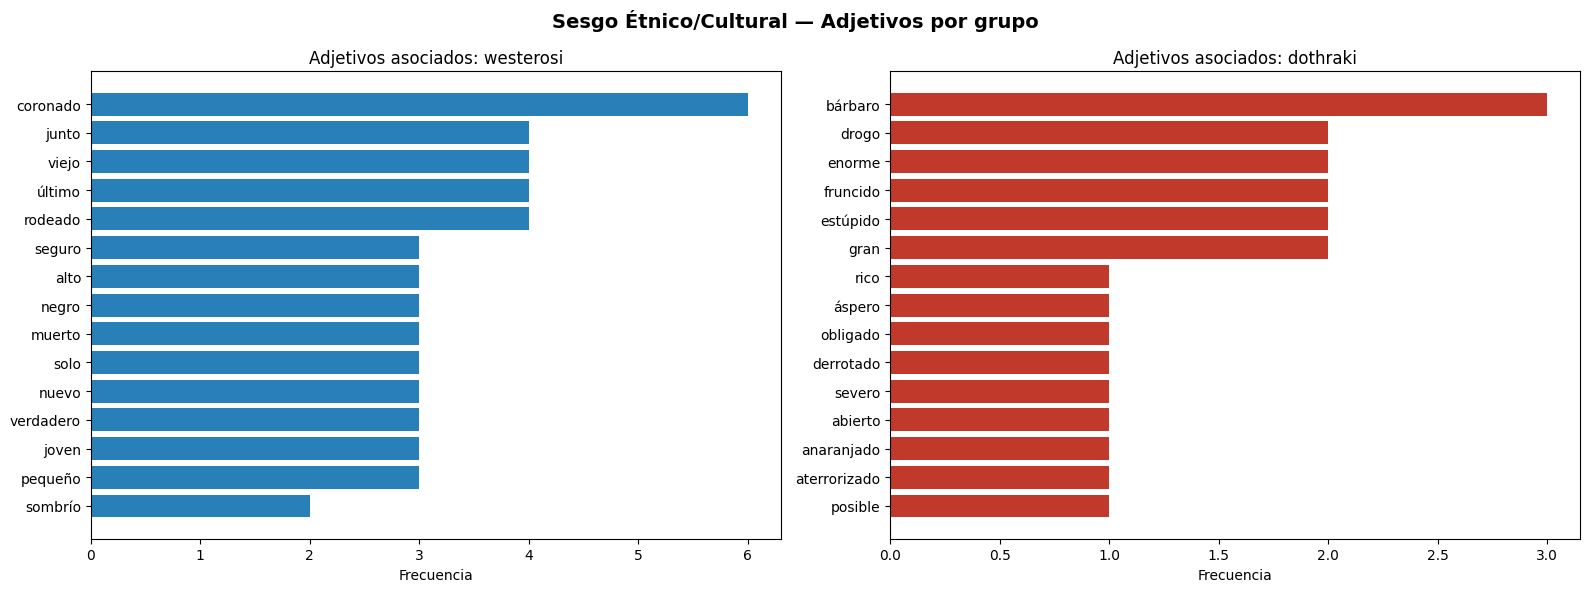

In [ ]:
# %% [sesgo_3_adjetivos_etnia]
ETHNIC_TERMS_FLAT = {
    "westerosi": ["Stark", "Lannister", "Baratheon", "Ned", "Robert", "Cersei"],
    "dothraki":  ["dothraki", "Drogo", "khalasar", "khal"],
}

ethnic_adj = defaultdict(list)

for text in df_libro['documents'].dropna():
    doc = nlp(text[:2000])
    for token in doc:
        if token.pos_ == "ADJ":
            window = doc[max(0, token.i-5):min(len(doc), token.i+5)]
            for w in window:
                for group, terms in ETHNIC_TERMS_FLAT.items():
                    if w.text in terms:
                        ethnic_adj[group].append(token.lemma_.lower())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
group_colors = {'westerosi': '#2980B9', 'dothraki': '#C0392B'}

for ax, (group, adjs) in zip(axes, ethnic_adj.items()):
    top = Counter(adjs).most_common(15)
    if not top:
        ax.set_title(f"Sin datos: {group}")
        continue
    words, counts = zip(*top)
    ax.barh(list(words)[::-1], list(counts)[::-1], color=group_colors.get(group, 'gray'))
    ax.set_title(f"Adjetivos asociados: {group}", fontsize=12)
    ax.set_xlabel("Frecuencia")

plt.suptitle("Sesgo Étnico/Cultural — Adjetivos por grupo", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

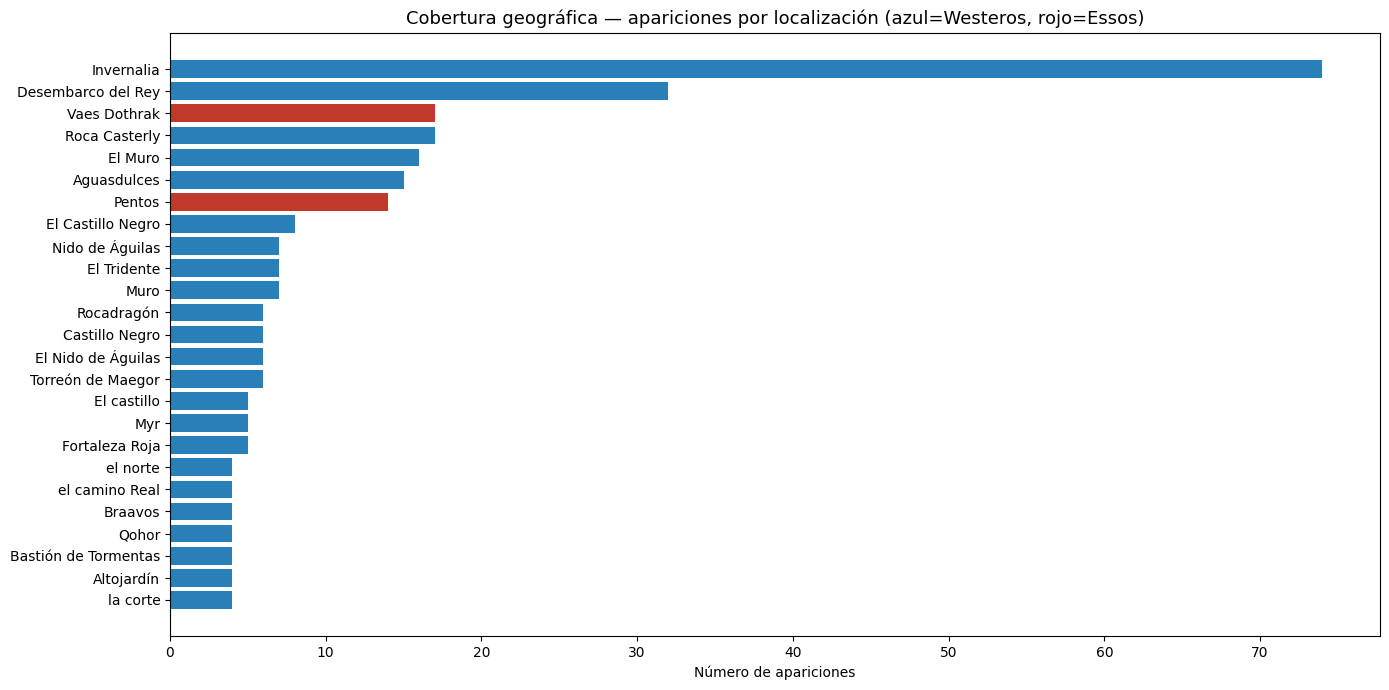

In [ ]:
# %% [sesgo_3_cobertura_geografica]
all_locations = []
for locs in df_libro['locations'].dropna():
    for loc in str(locs).split(','):
        loc = loc.strip()
        if loc:
            all_locations.append(loc)

loc_counts = Counter(all_locations).most_common(25)
loc_df = pd.DataFrame(loc_counts, columns=['location', 'n_chunks'])

essos_locs = {"Vaes Dothrak", "Essos", "Pentos", "las Ciudades Libres"}
loc_df['region'] = loc_df['location'].apply(
    lambda x: 'Essos' if any(e.lower() in x.lower() for e in essos_locs) else 'Westeros'
)

colors_geo = ['#C0392B' if r == 'Essos' else '#2980B9' for r in loc_df['region']]
fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(loc_df['location'][::-1], loc_df['n_chunks'][::-1], color=colors_geo[::-1])
ax.set_title("Cobertura geográfica — apariciones por localización (azul=Westeros, rojo=Essos)", fontsize=13)
ax.set_xlabel("Número de apariciones")
plt.tight_layout()
plt.show()